# Data Exploration

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
articles = pd.read_csv("../data/articles_metadata.csv")
clicks = pd.read_csv("../data/clicks_sample.csv")
embeddings = pd.read_pickle("../data/articles_embeddings.pickle")

print("Articles")
display(articles.head())
print("\nClicks")
display(clicks.head())

Articles


,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162



Clicks


,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2


In [6]:
len(embeddings)

364047

## Articles metadata

In [10]:
articles.info()

<class 'pandas.DataFrame'>
RangeIndex: 364047 entries, 0 to 364046
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   article_id     364047 non-null  int64
 1   category_id    364047 non-null  int64
 2   created_at_ts  364047 non-null  int64
 3   publisher_id   364047 non-null  int64
 4   words_count    364047 non-null  int64
dtypes: int64(5)
memory usage: 13.9 MB


In [ ]:
print(f"Date min: {articles['created_at_ts'].apply(lambda x: pd.Timestamp(x, unit='ms')).min()}")
print(f"Date max: {articles['created_at_ts'].apply(lambda x: pd.Timestamp(x, unit='ms')).max()}")
print(f"Number of unique articles: {articles['article_id'].nunique()}")
print(f"Number of unique category: {articles['category_id'].nunique()}")
print(f"Number of unique publishers: {articles['publisher_id'].nunique()}")


Date min: 2006-09-27 11:14:35
Date max: 2018-03-13 12:12:30
Number of unique articles: 364047
Number of unique category: 461
Number of unique publishers: 1
Number of missing values in articles: 0


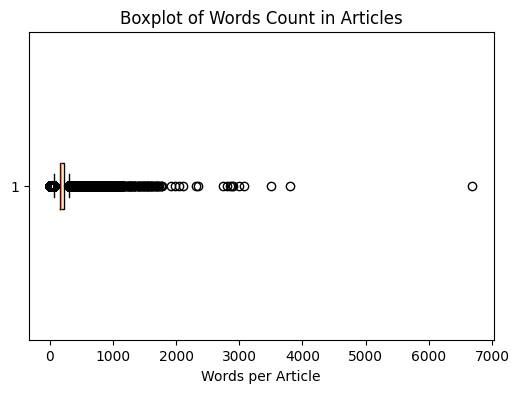

In [15]:
plt.figure(figsize=(6, 4))
plt.boxplot(articles['words_count'], vert=False)
plt.xlabel('Words per Article')
plt.title('Boxplot of Words Count in Articles')
plt.show()

In [16]:
articles.describe()

,article_id,category_id,created_at_ts,publisher_id,words_count
count,364047.000000,364047.000000,3.640470e+05,364047.0,364047.000000
mean,182023.000000,283.108239,1.474070e+12,0.0,190.897727
std,105091.461061,136.723470,4.293038e+10,0.0,59.502766
min,0.000000,0.000000,1.159356e+12,0.0,0.000000
25%,91011.500000,199.000000,1.444925e+12,0.0,159.000000
50%,182023.000000,301.000000,1.489422e+12,0.0,186.000000
75%,273034.500000,399.000000,1.509891e+12,0.0,218.000000
max,364046.000000,460.000000,1.520943e+12,0.0,6690.000000


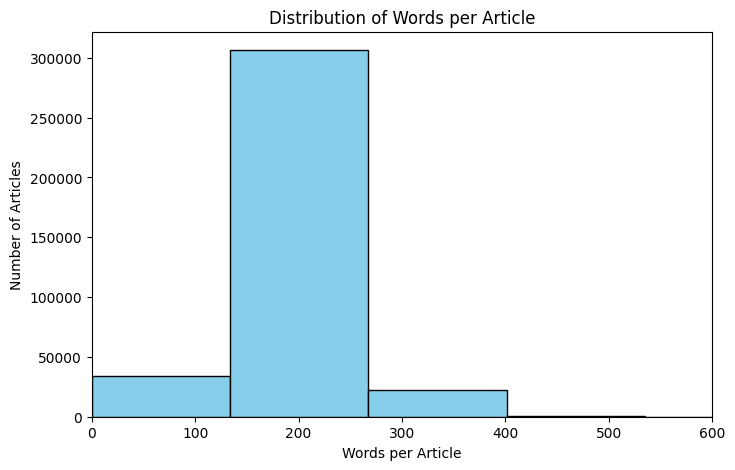

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(articles['words_count'], bins=50, color='skyblue', edgecolor='black')
plt.xlim([0,600])
plt.xlabel('Words per Article')
plt.ylabel('Number of Articles')
plt.title('Distribution of Words per Article')
plt.show()

In [24]:
# Missing values
print("Articles missing values:")
print(articles.isnull().sum())

Articles missing values:
article_id       0
category_id      0
created_at_ts    0
publisher_id     0
words_count      0
dtype: int64


In [25]:
# Get duplicates
duplicates = articles[articles.duplicated(subset='article_id', keep=False)]
print(f"Number of duplicate articles: {len(duplicates)}")
print("Duplicate article IDs:")
print(duplicates['article_id'].unique())

Number of duplicate articles: 0
Duplicate article IDs:
[]


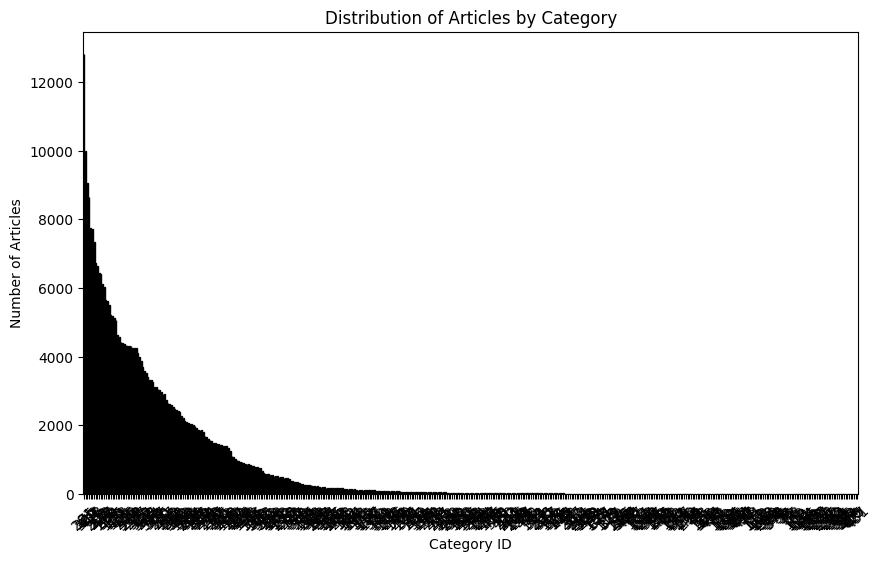

In [10]:
# Distribution of articles per categories
plt.figure(figsize=(10, 6))
articles['category_id'].value_counts().plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel('Category ID')
plt.ylabel('Number of Articles')
plt.title('Distribution of Articles by Category')
plt.xticks(rotation=45)
plt.show()

## Clicks sample

In [19]:
clicks.info()

<class 'pandas.DataFrame'>
RangeIndex: 1883 entries, 0 to 1882
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   user_id              1883 non-null   int64
 1   session_id           1883 non-null   int64
 2   session_start        1883 non-null   int64
 3   session_size         1883 non-null   int64
 4   click_article_id     1883 non-null   int64
 5   click_timestamp      1883 non-null   int64
 6   click_environment    1883 non-null   int64
 7   click_deviceGroup    1883 non-null   int64
 8   click_os             1883 non-null   int64
 9   click_country        1883 non-null   int64
 10  click_region         1883 non-null   int64
 11  click_referrer_type  1883 non-null   int64
dtypes: int64(12)
memory usage: 176.7 KB


In [22]:
print(f"Number of unique users: {clicks['user_id'].nunique()}")
print(f"Average of clicks per articles: {clicks['click_article_id'].value_counts().mean():.2f}")
print(f"Average of clicks per user: {clicks['user_id'].value_counts().mean():.2f}")

Number of unique users: 707
Average of clicks per articles: 5.83
Average of clicks per user: 2.66


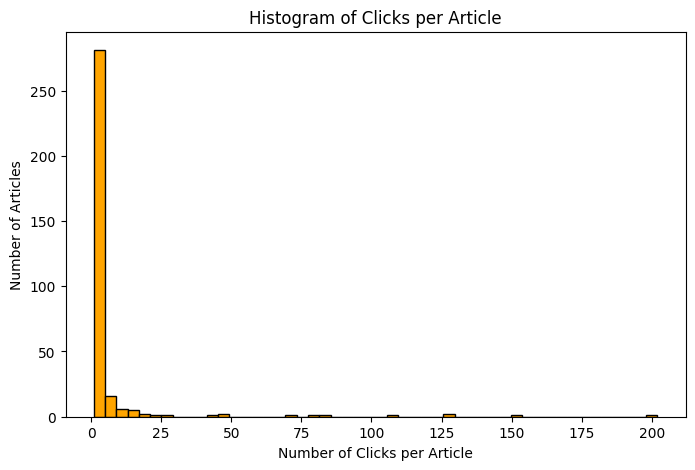

In [21]:
click_counts = clicks['click_article_id'].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(click_counts, bins=50, color='orange', edgecolor='black')
plt.xlabel('Number of Clicks per Article')
plt.ylabel('Number of Articles')
plt.title('Histogram of Clicks per Article')
plt.show()

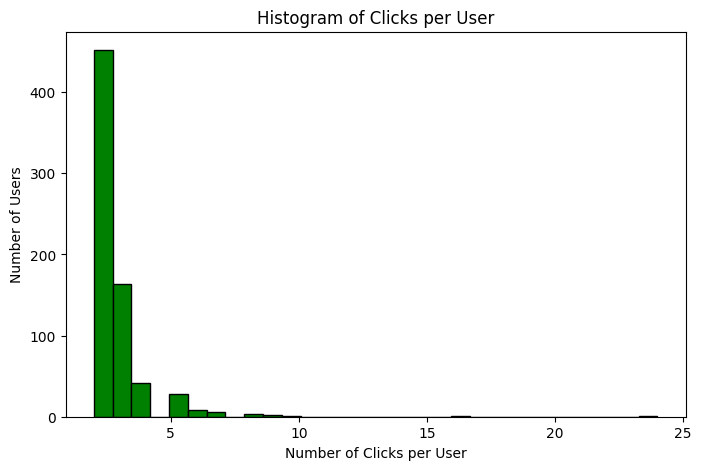

In [23]:
user_click_counts = clicks['user_id'].value_counts()

plt.figure(figsize=(8, 5))
plt.hist(user_click_counts, bins=30, color='green', edgecolor='black')
plt.xlabel('Number of Clicks per User')
plt.ylabel('Number of Users')
plt.title('Histogram of Clicks per User')
plt.show()

In [29]:
# Missing values
print("Clicks missing values:")
print(clicks.isnull().sum())
# Get duplicates
click_duplicates = clicks[clicks.duplicated(subset=['user_id', 'click_article_id'], keep=False)]
print(f"Number of duplicate clicks: {len(click_duplicates)}")

Clicks missing values:
user_id                0
session_id             0
session_start          0
session_size           0
click_article_id       0
click_timestamp        0
click_environment      0
click_deviceGroup      0
click_os               0
click_country          0
click_region           0
click_referrer_type    0
dtype: int64
Number of duplicate clicks: 0


## Clicks

In [6]:
# Make a unique dataframe of clicks using data/clicks/*csv files
import glob
click_files = glob.glob("../data/clicks/*.csv")
clicks_full = pd.concat((pd.read_csv(f) for f in click_files), ignore_index=True)
print(f"Total clicks in full dataset: {len(clicks_full)}")
print(clicks_full.info())

Total clicks in full dataset: 2988181
<class 'pandas.DataFrame'>
RangeIndex: 2988181 entries, 0 to 2988180
Data columns (total 12 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   user_id              object
 1   session_id           object
 2   session_start        object
 3   session_size         object
 4   click_article_id     object
 5   click_timestamp      object
 6   click_environment    object
 7   click_deviceGroup    object
 8   click_os             object
 9   click_country        object
 10  click_region         object
 11  click_referrer_type  object
dtypes: object(12)
memory usage: 273.6+ MB
None


In [33]:
# Find if missing values in clicks_full
print("Full Clicks missing values:")
print(clicks_full.isnull().sum())

# Find duplicates in clicks_full
print(f"Number of duplicate clicks in full dataset: {clicks_full.duplicated().sum()}")

Full Clicks missing values:
user_id                0
session_id             0
session_start          0
session_size           0
click_article_id       0
click_timestamp        0
click_environment      0
click_deviceGroup      0
click_os               0
click_country          0
click_region           0
click_referrer_type    0
dtype: int64
Number of duplicate clicks in full dataset: 0


In [35]:
# Optimize DF
# Define timestamps columns
timestamp_cols = ["session_start", "click_timestamp"]

# Convert timestamp columns to datetime and numeric types to best integer type to save memory
clicks_full[timestamp_cols] = clicks_full[timestamp_cols].apply(pd.to_datetime, unit='ms')
clicks_full['user_id'] = clicks_full['user_id'].astype('int32')
clicks_full['click_article_id'] = clicks_full['click_article_id'].astype('int32')

clicks_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 2988181 entries, 0 to 2988180
Data columns (total 12 columns):
 #   Column               Dtype         
---  ------               -----         
 0   user_id              int32         
 1   session_id           object        
 2   session_start        datetime64[ms]
 3   session_size         object        
 4   click_article_id     int32         
 5   click_timestamp      datetime64[ms]
 6   click_environment    object        
 7   click_deviceGroup    object        
 8   click_os             object        
 9   click_country        object        
 10  click_region         object        
 11  click_referrer_type  object        
dtypes: datetime64[ms](2), int32(2), object(8)
memory usage: 250.8+ MB


In [41]:
# Where are the users located?
# Agregate clicks by user_id and get the most common location
user_locations = clicks_full.groupby('user_id')['click_country'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
print(user_locations.value_counts().head(10))

click_country
1     309375
10      5879
11      3084
8        890
9        757
6        751
2        632
3        451
5        378
7        365
Name: count, dtype: int64


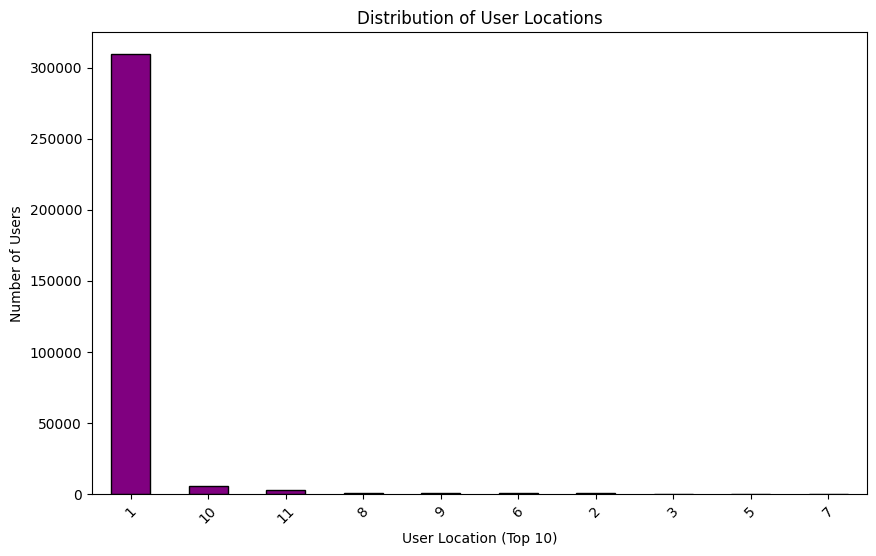

In [44]:
# Plot the distribution of user locations and colors for the regions
plt.figure(figsize=(10, 6))
user_locations.value_counts().head(10).plot(kind='bar', color='purple', edgecolor='black', figsize=(10, 6))
plt.xlabel('User Location (Top 10)')
plt.ylabel('Number of Users')
plt.title('Distribution of User Locations')
plt.xticks(rotation=45)
plt.show()

In [8]:
print(
    "Can a user can have read the same article id multiple times in a session?"
    "\n===================================================================="
)
print(
    clicks_full.groupby(["user_id", "session_id", "click_article_id"])
    .size()
    .reset_index(name="count")
    .groupby("count")
    .size()
    .rename_axis(
        "N_times | Count of users who have clicked on the same article id once or more times in the same session",
        axis=0,
    ),
)

print(
    "Can a user can have read the same article id multiple times through different sessions?"
    "\n======================================================================================="
)
print(
    clicks_full.groupby(["user_id", "click_article_id"])
    .size()
    .reset_index(name="count")
    .groupby("count")
    .size()
    .rename_axis(
        "N_times | Count of users who have clicked on the same article id once or more times through different sessions",
        axis=0,
    ),
)

Can a user can have read the same article id multiple times in a session?
N_times | Count of users who have clicked on the same article id once or more times in the same session
1    2988181
dtype: int64
Can a user can have read the same article id multiple times through different sessions?
N_times | Count of users who have clicked on the same article id once or more times through different sessions
1     2916835
2       31459
3        1869
4         343
5          95
6          42
7          22
8          14
9           7
10          7
12          3
13          6
16          2
17          1
30          1
31          1
33          3
dtype: int64


In [ ]:
# Articles popularity
article_popularity = clicks_full['click_article_id'].value_counts().reset_index()
article_popularity.columns = ['article_id', 'click_count']
print(article_popularity.head())


   article_id  click_count
0      160974        37213
1      272143        28943
2      336221        23851
3      234698        23499
4      123909        23122


## Merging DF

In [13]:
df = clicks_full.merge(articles, left_on='click_article_id', right_on='article_id', how='left')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2988181 entries, 0 to 2988180
Data columns (total 17 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   user_id              object
 1   session_id           object
 2   session_start        object
 3   session_size         object
 4   click_article_id     object
 5   click_timestamp      object
 6   click_environment    object
 7   click_deviceGroup    object
 8   click_os             object
 9   click_country        object
 10  click_region         object
 11  click_referrer_type  object
 12  article_id           int64 
 13  category_id          int64 
 14  created_at_ts        int64 
 15  publisher_id         int64 
 16  words_count          int64 
dtypes: int64(5), object(12)
memory usage: 387.6+ MB
None


In [14]:
df.head()

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,article_id,category_id,created_at_ts,publisher_id,words_count
0,93863,1507865792177843,1507865792000,2,96210,1507865832925,4,3,2,1,21,2,96210,209,1507798791000,0,274
1,93863,1507865792177843,1507865792000,2,158094,1507865862925,4,3,2,1,21,2,158094,281,1507803751000,0,223
2,294036,1507865795185844,1507865795000,2,20691,1507865819095,4,3,20,1,9,2,20691,9,1507826236000,0,226
3,294036,1507865795185844,1507865795000,2,96210,1507865849095,4,3,20,1,9,2,96210,209,1507798791000,0,274
4,77136,1507865796257845,1507865796000,2,336245,1507866133178,4,3,2,1,25,2,336245,437,1507785531000,0,150


In [ ]:
datetime_cols = ['session_start', 'click_timestamp', 'created_at_ts']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], unit='ms')

# COnvert numeric columns to best integer type to save memory
for col in df.columns:
    if col not in datetime_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce', downcast='integer')

df = df.drop(columns=['click_article_id'])

df.info()

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2988181 entries, 0 to 2988180
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   user_id              int32         
 1   session_id           int64         
 2   session_start        datetime64[ms]
 3   session_size         int8          
 4   click_timestamp      datetime64[ms]
 5   click_environment    int8          
 6   click_deviceGroup    int8          
 7   click_os             int8          
 8   click_country        int8          
 9   click_region         int8          
 10  click_referrer_type  int8          
 11  article_id           int32         
 12  category_id          int16         
 13  created_at_ts        datetime64[ms]
 14  publisher_id         int8          
 15  words_count          int16         
dtypes: datetime64[ms](3), int16(2), int32(2), int64(1), int8(8)
memory usage: 148.2 MB


### Most popular articles

In [31]:
# find the top 10 most popular articles according to the number of clicks
top_articles = df['article_id'].value_counts().head(10).reset_index()
top_articles.columns = ['article_id', 'click_count']
# Add the category_id to the top_articles dataframe
top_articles = top_articles.merge(articles[['article_id', 'category_id']], on='article_id', how='left')
print(top_articles)

   article_id  click_count  category_id
0      160974        37213          281
1      272143        28943          399
2      336221        23851          437
3      234698        23499          375
4      123909        23122          250
5      336223        21855          437
6       96210        21577          209
7      162655        21062          281
8      183176        20303          301
9      168623        19526          297


In [27]:
# Most popular categories
top_categories = df['category_id'].value_counts().head(10).reset_index()
top_categories.columns = ['category_id', 'click_count']
print(top_categories)

   category_id  click_count
0          281       370843
1          375       268257
2          412       178894
3          437       157085
4          250       140454
5          331       115901
6          399       104464
7          209        83750
8          418        67119
9          118        64216


## Embeddings

In [22]:
print(f"Embeddings type : {type(embeddings)}")
print(f"Embeddings shape : {embeddings.shape}")
print(f"Show first Vector: \n {embeddings[0]}")

Embeddings type : <class 'numpy.ndarray'>
Embeddings shape : (364047, 250)
Show first Vector: 
 [-0.16118301 -0.95723313 -0.13794445  0.05085534  0.83005524  0.90136534
 -0.33514765 -0.55956066 -0.50060284  0.16518293  0.4284342   0.3550556
  0.87443674 -0.52888286  0.6254872   0.2689198  -0.8228351  -0.703853
 -0.62584543 -0.15285493 -0.6662412   0.04329487  0.1786375   0.04689008
  0.5945311  -0.18334764  0.19510683 -0.46763963 -0.30480695  0.35317516
  0.27818817  0.5386231  -0.37120935  0.48989806 -0.10383289  0.11917368
  0.13243659 -0.62108386 -0.45331132  0.34662652 -0.06174106 -0.7305939
 -0.38411567 -0.94075835  0.06134219  0.4825816   0.28968322 -0.62269634
 -0.05000444  0.42151213 -0.24257636  0.6687105  -0.509004   -0.46179956
  0.04390178  0.28848746  0.4498246  -0.28486234  0.916729    0.70312876
  0.85167396 -0.6272441   0.35773164  0.3901894   0.65293527  0.1036527
  0.79829276 -0.10254639 -0.2045143   0.37861153 -0.09026147 -0.2511573
  0.3259828   0.08588007 -0.180564

In [ ]:
# Are embeddings linked to article_id?
article_ids = articles['article_id'].tolist()
if len(article_ids) != len(embeddings):
    raise ValueError("⚠️ Articles count different from vectors count!")
else:
    print("Mapping articles to embedding vectors...")
    article_id_to_embedding = {
        aid: embeddings[i]
        for i, aid in enumerate(article_ids)
    }

sample_ids = np.random.choice(list(article_id_to_embedding.keys()), size=5, replace=False)
print("\n🧪 Articles vector sample:")
for aid in sample_ids:
    print(f"Article ID {aid} → Vector: {article_id_to_embedding[aid][:5]}")

Linking article_id to embedding...

🧪 Articles vector sample:
Article ID 116050 → Vector: [ 0.0222356  -0.96894425  0.86703503  0.18964642  0.49684027]
Article ID 21606 → Vector: [ 0.7392945  -0.9721414   0.26562148 -0.03987416  0.7360078 ]
Article ID 284820 → Vector: [-0.82959193 -0.96147203 -0.7257465  -0.79664785 -0.05611889]
Article ID 185674 → Vector: [ 0.6658226  -0.9718393   0.87091976 -0.36835253  0.35427257]
Article ID 119319 → Vector: [-0.50236034 -0.9650479   0.456096   -0.13546012  0.63662577]
